# Time-Series Evaluation Warning

**Project question:** What validation design reproduces the information available at a future forecast origin?

By the end of this notebook, you should be able to:

- explain why random splitting violates temporal deployment order
- compare a random split with a last-period holdout
- design a rolling or expanding-window transfer evaluation

This notebook is a demonstration, not a homework assignment. The data are
synthetic and were generated for teaching; numerical results should not be
interpreted as evidence about a real organization or population.

In [1]:

from lite_setup import ensure_packages
await ensure_packages()

Using the current Python environment.


In [2]:

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
if not DATA.exists():
    raise FileNotFoundError("Open this notebook from the JupyterLite files root so data/ is available.")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv(DATA / 'evaluation_timeseries.csv').sort_values('month').reset_index(drop=True)
X = pd.get_dummies(df[['trend', 'season']].astype({'season': 'category'}), drop_first=True, dtype=float)
y = df['demand']

def rmse(actual, predicted):
    return float(np.sqrt(mean_squared_error(actual, predicted)))

In [5]:
X_rand_train, X_rand_test, y_rand_train, y_rand_test = train_test_split(
    X, y, test_size=0.25, random_state=4031
)
model_random = LinearRegression().fit(X_rand_train, y_rand_train)
rmse_random = rmse(y_rand_test, model_random.predict(X_rand_test))

cut = int(len(df) * 0.75)
model_time = LinearRegression().fit(X.iloc[:cut], y.iloc[:cut])
rmse_time = rmse(y.iloc[cut:], model_time.predict(X.iloc[cut:]))
pd.DataFrame({
    'design': ['invalid random split for forecasting', 'last-period holdout'],
    'rmse': [rmse_random, rmse_time],
})

,design,rmse
0,invalid random split for forecasting,8.256708
1,last-period holdout,18.992377


Text(0.5, 1.0, 'Last-period holdout preserves forecast order')

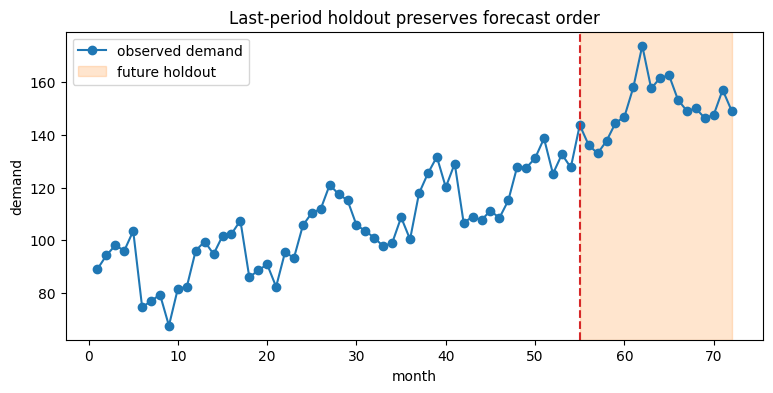

In [6]:
plt.figure(figsize=(9, 4))
plt.plot(df['month'], y, marker='o', label='observed demand')
plt.axvspan(df['month'].iloc[cut], df['month'].iloc[-1], color='tab:orange', alpha=0.2, label='future holdout')
plt.axvline(df['month'].iloc[cut], color='tab:red', linestyle='--')
plt.xlabel('month')
plt.ylabel('demand')
plt.legend()
plt.title('Last-period holdout preserves forecast order')

**Interpretation:** Random splitting lets the training set contain observations later than some test observations, so it does not mimic forecasting. The RMSE values are not competing valid estimates; only the time-respecting design answers the deployment question.

**Transfer exercise:** Draw two or more forecast origins for your own ordered data. At each origin, list the observations available for training and the future period used for validation. This expanding-window design is preferable to random K-fold CV.